# Data preparation and train / test split

Turns the original `oedi_data.xlsx` into `data.xlsx`, `train.csv` and `test.csv`.

| Step | What happens |
|---|---|
| 1 | Load the `data` sheet |
| 2 | Remove rows where `PR` is missing or 0 |
| 3 | Bin `PR` into `PR_class` (Low / Medium / High) |
| 4 | Drop attributes with over 95% of values missing |
| 5 | Drop the redundant `rain` column |
| 6 | Set implausible `wind_speed_mean` values (above 25) to missing |
| 7 | Add `month` and `season`, drop `Date` and `randid` |
| 8 | Save `data.xlsx` |
| 9 | Stratified 80 / 20 split |
| 10 | Drop attributes that are constant in the training set |
| 11 | Impute missing values (mean for numeric, mode for nominal) |
| 12 | Normalise numeric attributes to 0 - 1 |
| 13 | Save `train.csv` and `test.csv` |

Steps 1 - 8 learn nothing from the data, so they are done before the split. Steps 10 - 12 are fitted on the training set only and then applied to both sets.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

## 1. Load

One row is one day at one PV site.

In [2]:
raw = pd.read_excel("oedi_data.xlsx", sheet_name="data")
print(raw.shape, "-", raw.randid.nunique(), "sites,", raw.Date.min().date(), "to", raw.Date.max().date())
raw.head()

(51504, 38) - 174 sites, 2018-02-22 to 2020-03-01


,randid,Date,NOAAClimRegion,TempZone,HumidZone,bin_PlantSize_kW,plant_age_months,active_snow_tickets,snow_bin_ticket_minutes,snow_affected_assets,...,storm_affected_assets,storm_production_level,lightning,storm,duration_minutes_storm,nearest_storm,flood,duration_minutes_flood,nearest_flood,rain
0,C2S1,2018-04-01,West,T6,H4,large,19.0,No,NaN,NaN,...,NaN,Unknown,0,0.0,0,2420,0.0,0,2255,0.0
1,C2S1,2018-04-02,West,T6,H4,large,19.0,No,NaN,NaN,...,NaN,Unknown,0,0.0,0,2420,0.0,0,2255,0.0
2,C2S1,2018-04-03,West,T6,H4,large,19.0,No,NaN,NaN,...,NaN,Unknown,0,0.0,0,2420,0.0,0,2255,0.0
3,C2S1,2018-04-04,West,T6,H4,large,19.0,No,NaN,NaN,...,NaN,Unknown,0,0.0,0,2420,0.0,0,2255,0.0
4,C2S1,2018-04-05,West,T6,H4,large,19.0,No,NaN,NaN,...,NaN,Unknown,0,0.0,0,2420,0.0,0,2255,0.0


## 2. Remove rows with an unusable PR

`PR` is the target. Rows where it is missing cannot be labelled, and a PR of exactly 0 is treated as a recording error.

Very low (0 < PR < 0.1) and above-1 values are kept: they are plausible (outage or snow days, cold clear days) and PR never exceeds 1.2.

In [3]:
pr_missing = raw.PR.isna()
pr_zero = raw.PR == 0

pd.Series({
    "rows": len(raw),
    "PR missing (removed)": pr_missing.sum(),
    "PR == 0 (removed)": pr_zero.sum(),
    "0 < PR < 0.1 (kept)": raw.PR.between(0, 0.1, inclusive="neither").sum(),
    "PR > 1 (kept)": (raw.PR > 1).sum(),
}).to_frame("count")

,count
rows,51504
PR missing (removed),1564
PR == 0 (removed),6343
0 < PR < 0.1 (kept),1001
PR > 1 (kept),457


In [4]:
df = raw[~pr_missing & ~pr_zero].copy()
print(f"{len(raw)} -> {len(df)} rows ({len(raw) - len(df)} removed), {df.randid.nunique()} of {raw.randid.nunique()} sites remain")

51504 -> 43597 rows (7907 removed), 154 of 174 sites remain


## 3. Bin PR into three classes

| Class | Interval |
|---|---|
| Low | PR < 0.7 |
| Medium | 0.7 <= PR <= 0.8 |
| High | PR > 0.8 |

`PR_class` replaces `PR`, so the numeric target cannot leak into the features.

In [5]:
pr_class = np.select([df.PR < 0.7, df.PR <= 0.8], ["Low", "Medium"], default="High")
df.insert(df.columns.get_loc("PR"), "PR_class", pr_class)

print("rows exactly on 0.7 or 0.8:", df.PR.isin([0.7, 0.8]).sum())
summary = df.groupby("PR_class").PR.agg(["count", "min", "max"]).loc[["Low", "Medium", "High"]]
summary.assign(**{"%": summary["count"] / len(df) * 100})

rows exactly on 0.7 or 0.8: 0


,count,min,max,%
PR_class,,,,
Low,10100,0.000212,0.699976,23.166732
Medium,20057,0.700019,0.799994,46.005459
High,13440,0.800003,1.199583,30.827809


Number of rows in each class.

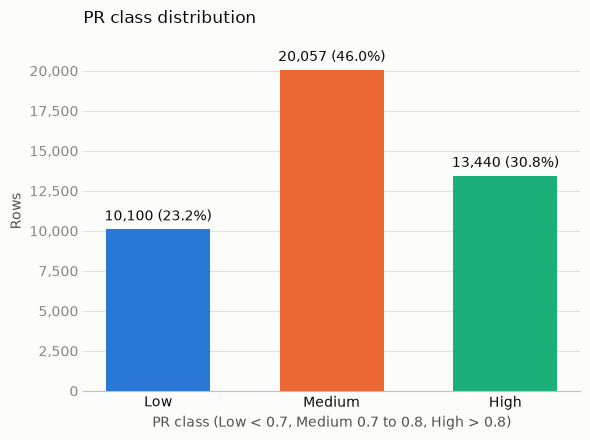

In [6]:
import matplotlib.pyplot as plt

colors = {"Low": "#2a78d6", "Medium": "#eb6834", "High": "#1baf7a"}
counts = df.PR_class.value_counts().loc[list(colors)]

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.bar(counts.index, counts, width=0.6, color=list(colors.values()))
ax.bar_label(bars, [f"{n:,} ({n / len(df):.1%})" for n in counts], padding=4, color="#0b0b0b")

ax.set_title("PR class distribution", loc="left", color="#0b0b0b")
ax.set_xlabel("PR class (Low < 0.7, Medium 0.7 to 0.8, High > 0.8)", color="#52514e")
ax.set_ylabel("Rows", color="#52514e")
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781", length=0)
ax.tick_params(axis="x", labelcolor="#0b0b0b")
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")

fig.tight_layout()
fig.savefig("pr_class_distribution.png", dpi=200)
plt.show()

In [7]:
df = df.drop(columns="PR")

## 4. Drop attributes with over 95% of values missing

Six O&M ticket attributes are almost entirely blank (a blank means no ticket was open that day), so they are dropped. Whether a ticket was open is still recorded in `active_snow_tickets`, `storm_active_tickets` and the `*_production_level` attributes.

In [8]:
missing = df.isna().mean() * 100
mostly_missing = missing[missing > 95]

df = df.drop(columns=mostly_missing.index)
print("highest remaining:", missing.drop(mostly_missing.index).idxmax(), f"{missing.drop(mostly_missing.index).max():.1f}%")
mostly_missing.round(1).to_frame("missing_%")

highest remaining: cumulative_snow_mm 22.1%


,missing_%
snow_bin_ticket_minutes,98.8
snow_affected_assets,98.8
hurr_bin_ticket_minutes,99.3
hurr_affected_assets,99.3
storm_bin_ticket_minutes,99.6
storm_affected_assets,99.6


## 5. Drop redundant columns

`rain` is just `rain_value_mm > 0`, so it is dropped.

`snow_value_mm` and `total_daily_snow_mm` share a description in the data dictionary but hold different values, so both are kept.

In [9]:
known = df.rain.notna()
print("rain missing exactly where rain_value_mm is missing:", (df.rain.isna() == df.rain_value_mm.isna()).all())
print("rain == (rain_value_mm > 0) on all other rows:      ", (df.rain[known] == (df.rain_value_mm[known] > 0)).all())

both = df.snow_value_mm.notna() & df.total_daily_snow_mm.notna()
print("snow columns differ on", (df.snow_value_mm[both] != df.total_daily_snow_mm[both]).sum(), "of", both.sum(), "rows")

df = df.drop(columns="rain")

rain missing exactly where rain_value_mm is missing: True
rain == (rain_value_mm > 0) on all other rows:       True
snow columns differ on 1743 of 38967 rows


## 6. Implausible wind speeds

A daily mean wind speed above 25 is not physically plausible (values reach 2,672, while 99% of days are below about 10). All such values come from ten sites that otherwise read normally, so they are treated as recording errors.

Only the wind value is set to missing. The rows are kept and the value is imputed after the split (step 11).

In [10]:
WIND_MAX = 25
bad_wind = df.wind_speed_mean > WIND_MAX

print(bad_wind.sum(), "values above", WIND_MAX, "at", df.randid[bad_wind].nunique(), "sites:", sorted(df.randid[bad_wind].unique()))
print("largest:", df.wind_speed_mean.nlargest(5).round(0).tolist())
print("PR class of these rows:", df.PR_class[bad_wind].value_counts().to_dict())

df.loc[bad_wind, "wind_speed_mean"] = np.nan
print("new maximum:", round(df.wind_speed_mean.max(), 2), "- rows kept:", len(df))

128 values above 25 at 10 sites: ['C3S30', 'C3S31', 'C3S32', 'C3S33', 'C3S34', 'C3S35', 'C3S36', 'C3S37', 'C3S38', 'C3S39']
largest: [2672.0, 1821.0, 1774.0, 1301.0, 1252.0]
PR class of these rows: {'Low': 91, 'Medium': 19, 'High': 18}
new maximum: 24.34 - rows kept: 43597


## 7. Date features

`Date` becomes `month` (1-12) and `season` (Dec-Feb Winter, Mar-May Spring, Jun-Aug Summer, Sep-Nov Autumn). `Date` and the site id `randid` are then dropped, as neither should be used as a feature.

In [11]:
seasons = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
           6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}

df.insert(0, "month", df.Date.dt.month)
df.insert(1, "season", df.month.map(seasons))
df = df.drop(columns=["Date", "randid"])

df.season.value_counts()

season
Autumn    12260
Winter    12129
Summer     9638
Spring     9570
Name: count, dtype: int64

## 8. Save the prepared data

The remaining missing values (weather and snow measurements) are left as they are here and imputed after the split (step 11).

In [12]:
df.to_excel("data.xlsx", sheet_name="data", index=False)
print(df.shape)

missing = df.isna().mean() * 100
missing[missing > 0].sort_values(ascending=False).round(1).to_frame("missing_%")

(43597, 31)


,missing_%
cumulative_snow_mm,22.1
rain_value_mm,19.9
wind_speed_mean,14.2
total_daily_snow_mm,10.6
snow_value_mm,10.5
hurricane,10.5
storm,10.5
flood,10.5
plant_age_months,0.3
snow_production_level,0.1


## 9. Stratified train / test split

80 / 20, stratified on `PR_class`, seed 42.

Limitation: the split is random over rows, so days from the same site appear in both sets. Test scores may be somewhat optimistic for sites the model has never seen.

In [13]:
train, test = train_test_split(df, test_size=0.2, stratify=df.PR_class, random_state=SEED)

split = pd.DataFrame({"train": train.PR_class.value_counts(), "test": test.PR_class.value_counts()})
split.assign(**{"train_%": split.train / split.train.sum() * 100, "test_%": split.test / split.test.sum() * 100})

,train,test,train_%,test_%
PR_class,,,,
Medium,16045,4012,46.00453,46.009174
High,10752,2688,30.82834,30.825688
Low,8080,2020,23.16713,23.165138


## 10. Attribute types and constant attributes

- **Nominal:** text attributes and the 0 / 1 indicators (`low_irradiation`, `lightning`, `hurricane`, `storm`, `flood`).
- **Numeric:** everything else.

An attribute with a single value in the training set carries no information, so it is dropped from both sets.

In [14]:
train, test = train.copy(), test.copy()

constant = [c for c in train.columns if train[c].nunique() == 1]
train, test = train.drop(columns=constant), test.drop(columns=constant)
print("constant, dropped:", constant)

attributes = train.columns.drop("PR_class")
indicators = [c for c in attributes if set(train[c].dropna()) <= {0, 1}]
nominal = [c for c in attributes if train[c].dtype.kind not in "iuf" or c in indicators]
numeric = [c for c in attributes if c not in nominal]

print(len(nominal), "nominal:", nominal)
print(len(numeric), "numeric:", numeric)

constant, dropped: ['HurricanePrep']
16 nominal: ['season', 'NOAAClimRegion', 'TempZone', 'HumidZone', 'bin_PlantSize_kW', 'active_snow_tickets', 'snow_production_level', 'low_irradiation', 'hurr_production_level', 'HurricanePostInspection', 'hurricane', 'storm_active_tickets', 'storm_production_level', 'lightning', 'storm', 'flood']
13 numeric: ['month', 'plant_age_months', 'snow_value_mm', 'total_daily_snow_mm', 'cumulative_snow_mm', 'nearest_hurricane', 'wind_speed_mean', 'rain_value_mm', 'nearest_rain', 'duration_minutes_storm', 'nearest_storm', 'duration_minutes_flood', 'nearest_flood']


## 11. Imputation

Missing numeric values are replaced by the column mean and missing nominal values by the column mode. Means and modes come from the training set only.

In [15]:
fill = pd.concat([train[numeric].mean(), train[nominal].mode().iloc[0]])

before = pd.DataFrame({"train_missing": train.isna().sum(), "test_missing": test.isna().sum(), "filled_with": fill})
train, test = train.fillna(fill), test.fillna(fill)
train[indicators], test[indicators] = train[indicators].astype(int), test[indicators].astype(int)

print("missing after imputation:", train.isna().sum().sum(), "train,", test.isna().sum().sum(), "test")
before[before.train_missing + before.test_missing > 0]

missing after imputation: 0 train, 0 test


,train_missing,test_missing,filled_with
cumulative_snow_mm,7638,1995,105.074792
flood,3641,936,0.0
hurr_production_level,10,2,Unknown
hurricane,3641,936,0.0
plant_age_months,115,21,37.755883
rain_value_mm,6963,1711,2.130321
snow_production_level,37,11,Unknown
snow_value_mm,3641,937,0.923146
storm,3641,936,0.0
total_daily_snow_mm,3684,946,2.685385


## 12. Normalisation

Numeric attributes are min-max scaled to 0 - 1: `(x - min) / (max - min)`, with min and max taken from the training set only. A test value outside the training range can therefore fall slightly below 0 or above 1.

Nominal attributes keep their labels.

In [16]:
low, high = train[numeric].min(), train[numeric].max()

train[numeric] = (train[numeric] - low) / (high - low)
test[numeric] = (test[numeric] - low) / (high - low)

pd.DataFrame({"train_min_was": low, "train_max_was": high,
              "test_min_now": test[numeric].min(), "test_max_now": test[numeric].max()})

,train_min_was,train_max_was,test_min_now,test_max_now
month,1.0,12.000000,0.0,1.000000
plant_age_months,-5.0,123.000000,0.0,1.000000
snow_value_mm,0.0,275.737309,0.0,0.799816
total_daily_snow_mm,0.0,301.904108,0.0,0.827066
cumulative_snow_mm,0.0,3614.551523,0.0,0.976444
nearest_hurricane,0.0,354.000000,0.0,1.000000
wind_speed_mean,0.0,24.343839,0.0,0.995713
rain_value_mm,0.0,185.644027,0.0,0.960382
nearest_rain,0.0,169.000000,0.0,1.000000
duration_minutes_storm,0.0,1440.000000,0.0,0.250000


## 13. Save

`train.csv` and `test.csv` are complete (no missing values) and ready for attribute selection.

In [17]:
train.to_csv("train.csv", index=False, quotechar="'")
test.to_csv("test.csv", index=False, quotechar="'")
print(train.shape, test.shape)
train.head()

(34877, 30) (8720, 30)


,month,season,NOAAClimRegion,TempZone,HumidZone,bin_PlantSize_kW,plant_age_months,active_snow_tickets,snow_production_level,PR_class,...,nearest_rain,storm_active_tickets,storm_production_level,lightning,storm,duration_minutes_storm,nearest_storm,flood,duration_minutes_flood,nearest_flood
39759,0.363636,Spring,Northwest,T5,H2,large,0.265625,No,Unknown,Medium,...,1.000000,No,Unknown,0,0,0.0,1.000000,0,0.0,1.000000
48039,0.818182,Autumn,Upper Midwest,T4,H4,small,0.046875,No,Unknown,Low,...,0.041420,No,Unknown,0,0,0.0,1.000000,0,0.0,0.007095
12457,0.818182,Autumn,West,T5,H4,small,0.406250,No,Unknown,Medium,...,0.088757,No,Unknown,0,0,0.0,0.058678,0,0.0,0.508204
40942,0.363636,Spring,Northwest,T4,H3,large,0.273438,No,Unknown,Medium,...,1.000000,No,Unknown,0,0,0.0,1.000000,0,0.0,1.000000
40305,0.727273,Autumn,Northwest,T4,H3,large,0.195312,Yes,Partial,High,...,1.000000,No,Unknown,0,0,0.0,1.000000,0,0.0,1.000000
